In [1]:
!pip install networkx

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

def build_tree_from_pairs(pairs):
    G = nx.DiGraph()

    for a, b in pairs:
        G.add_edge(a, b)

    root_candidates = [node for node in G.nodes if G.in_degree(node) == 0]
    if len(root_candidates) != 1:
        raise ValueError("There should be exactly one root node. Found: {}".format(root_candidates))
    root = root_candidates[0] if root_candidates else None
    return G, root

def check_relationships(pairs, friends):
    for pair in pairs:
        if pair in friends:
            print(f"{pair[0]} and {pair[1]} are friends.")
        else:
            print(f"{pair[0]} and {pair[1]} are not friends.")

def draw_tree(G, layout_choice="spring", root=None, friends=set()):
    if layout_choice == "spring":
        pos = nx.spring_layout(G)
    elif layout_choice == "planar":
        pos = nx.planar_layout(G)
    elif layout_choice == "spiral":
        pos = nx.spiral_layout(G)
    else:
        pos = nx.spring_layout(G)
    
    plt.figure(figsize=(12, 8))
    edge_styles = ['solid' if (u, v) in friends else 'dashed' for u, v in G.edges()]

    for (u, v), style in zip(G.edges(), edge_styles):
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], style=edge_styles, width=2)
    
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1000)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    plt.title("Tree Visualization with Friend Relationships")
    plt.show()

a and b are friends.
b and e are friends.
e and m are friends.
m and p are friends.
a and z are not friends.
b and q are not friends.


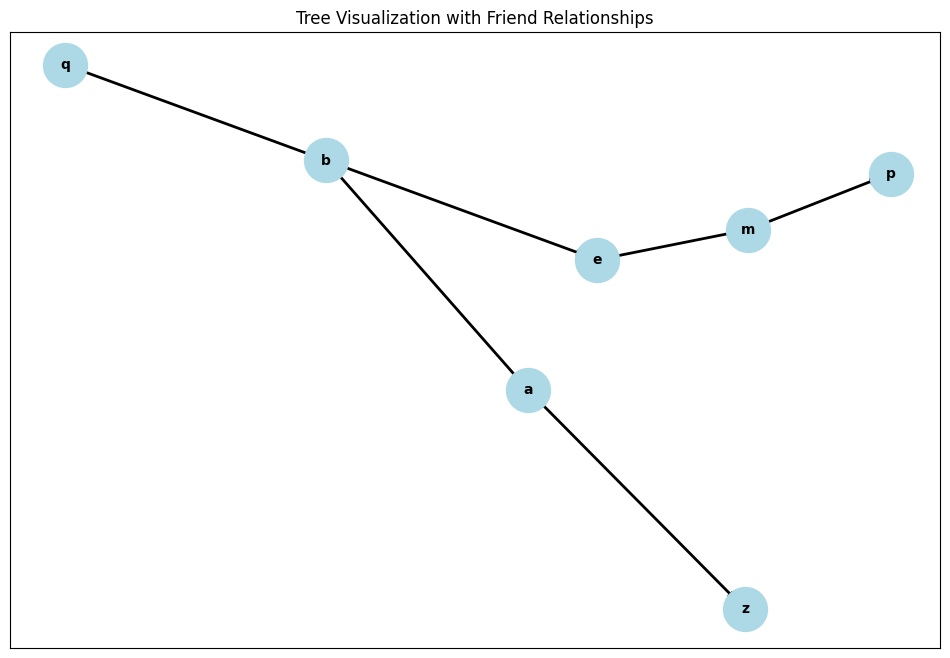

In [5]:
pairs = [('a', 'b'), ('b', 'e'), ('e', 'm'), ('m', 'p'), ('a', 'z'), ('b', 'q')]
friends = {('a', 'b'), ('b', 'e'), ('e', 'm'), ('m', 'p')}

tree, root = build_tree_from_pairs(pairs)
check_relationships(pairs, friends)
layout_choice = "spring"
draw_tree(tree, layout_choice, root, friends)